## Data Analysis

## Library and Data Imports

In [2]:
import pandas as pd
import numpy as np 
import ast
import string
from spellchecker import SpellChecker
import json
import seaborn as sns
import matplotlib.pyplot as plt


from nltk.stem import PorterStemmer
from IPython.display import display

from wordcloud import WordCloud, STOPWORDS


stemmer = PorterStemmer()

import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [3]:
survey_df = pd.read_csv('Data/Inbound/final_data_export.csv')

survey_df = survey_df[(survey_df['StartDate']!= 'Start Date') & (survey_df['Status']!= '{"ImportId":"status"}')].reset_index(drop=True)

survey_df.head(3)

,StartDate,EndDate,Status,IPAddress,Progress,Duration (in seconds),Finished,RecordedDate,ResponseId,RecipientLastName,RecipientFirstName,RecipientEmail,ExternalReference,LocationLatitude,LocationLongitude,DistributionChannel,UserLanguage,Q1,Q2_1,Q2_2,Q2_3,Q2_4,Q2_5,Q2_6,Q2_7,Q2_8,Q2_9,Q2_10,Q3_1,Q3_2,Q3_3,Q3_4,Q3_5,Q3_6,Q3_7,Q3_8,Q3_9,Q3_10,Q4,Q5#1_1,Q5#1_2,Q5#1_3,Q5#1_4,Q5#1_5,Q5#1_6,Q5#1_7,Q5#1_8,Q5#1_9,Q5#1_10,Q5#1_11,Q5#2_1_1,Q5#2_2_1,Q5#2_3_1,Q5#2_4_1,Q5#2_5_1,Q5#2_6_1,Q5#2_7_1,Q5#2_8_1,Q5#2_9_1,Q5#2_10_1,Q5#2_11_1,Q6_1,Q6_2,Q6_3,Q6_4,Q6_5,Q6_6,Q6_7,Q6_8,Q6_9,Q6_10,Q7_1,Q7_2,Q7_3,Q7_4,Q7_5,Q7_6,Q7_7,Q7_8,Q7_9,Q7_10,Q8,Q9#1_1,Q9#1_2,Q9#1_3,Q9#1_4,Q9#1_5,Q9#1_6,Q9#1_7,Q9#1_8,Q9#1_9,Q9#1_10,Q9#1_11,Q9#2_1_1,Q9#2_2_1,Q9#2_3_1,Q9#2_4_1,Q9#2_5_1,Q9#2_6_1,Q9#2_7_1,Q9#2_8_1,Q9#2_9_1,Q9#2_10_1,Q9#2_11_1,Q10_1,Q10_2,Q10_3,Q10_4,Q10_5,Q10_6,Q10_7,Q10_8,Q10_9,Q10_10,Q11_1,Q11_2,Q11_3,Q11_4,Q11_5,Q11_6,Q11_7,Q11_8,Q11_9,Q11_10,Q12,Q13#1_1,Q13#1_2,Q13#1_3,Q13#1_4,Q13#1_5,Q13#1_6,Q13#1_7,Q13#1_8,Q13#1_9,Q13#1_10,Q13#1_11,Q13#2_1_1,Q13#2_2_1,Q13#2_3_1,Q13#2_4_1,Q13#2_5_1,Q13#2_6_1,Q13#2_7_1,Q13#2_8_1,Q13#2_9_1,Q13#2_10_1,Q13#2_11_1,Q14,Q15,Q15_4_TEXT,Q16,Q17,Q17_5_TEXT
0,2025-04-30 11:21:17,2025-04-30 11:41:55,IP Address,184.58.198.91,100,1238,True,2025-04-30 11:41:56,R_1M0P04gYkqgIfoB,NaN,NaN,NaN,NaN,43.0818,-87.892,anonymous,EN,"I agree to participate, and I am 18 years or o...",Cozy,Peaceful,Homey,Nostalgic,Tranquil,Comforting,Harvesty,Intense,Hopeless,Chaotic,Peaceful,Peaceful,Light-hearted,Peaceful,Peaceful,Peaceful,No match,Intense,Dark,Dark,"Mood Term 4,Mood Term 10",NaN,NaN,NaN,NaN,"Light-hearted,Peaceful",NaN,NaN,NaN,NaN,NaN,"Dark,Intense",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cozy,Cute,Simple,Warm,Peaceful,Nostalgic,Satisfied,Fulfilled,Connected,Immersive,Peaceful,Cute,Light-hearted,Peaceful,Peaceful,Peaceful,No match,No match,No match,No match,Mood Term 6,NaN,NaN,NaN,NaN,NaN,NaN,"Light-hearted,Peaceful",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Intense,Anxious,Frustrated,Tormented,Tense,Haunting,Stressful,Overwhelming,Violent,Sextual,Intense,Intense,Intense,Horror,Intense,Horror,Intense,Intense,Dark,Sensual,"Mood Term 4,Mood Term 9",NaN,NaN,NaN,NaN,"Dark,Horror,Intense",NaN,NaN,NaN,NaN,"Dark,Horror,Intense",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,26-33,Female,NaN,No,NaN,NaN
1,2025-04-30 12:34:03,2025-04-30 12:39:20,IP Address,68.55.41.237,100,317,True,2025-04-30 12:39:21,R_6hA6yOKSGzPDXlp,NaN,NaN,NaN,NaN,42.3757,-85.4447,anonymous,EN,"I agree to participate, and I am 18 years or o...",Solemn,Cerebral,Calm,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Peaceful,Imaginative,Peaceful,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Calm,Cerebral,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Peaceful,Imaginative,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Depressing,Frustrating,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Sad,Mysterious,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50-57,Male,NaN,No,NaN,NaN
2,2025-04-30 14:30:54,2025-04-30 14:39:56,IP Address,184.58.199.136,100,541,True,2025-04-30 14:39:57,R_34jUAPsFHDjPeyy,NaN,NaN,NaN,NaN,43.0818,-87.892,anonymous,EN,"I agree to participate, and I am 18 years or o...",relaxing,engrossing,makes-you-think,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Peaceful,No match,Imaginative,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,creative,fun,relaxing,imaginative,explorative,NaN,NaN,NaN,NaN,NaN,Imaginative,Light-hearted,Peaceful,Imaginative,Adventurous,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,depressing,sad,gross,horror,NaN,NaN,NaN,NaN,NaN,NaN,Sad,Sad,Dark,Horror,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN

In [4]:
term_df = pd.read_csv('Data/Outbound/all_terms_cleaned_stemmed.csv')
term_df.head(3)

,metadata.ResponseId,metadata.Finished,metadata.Progress,metadata.TermTrack,metadata.QuestionId,QX_X.UserProvidedMoodTerm,QX_X.CleanedMoodTerm,QX_X.CleanedTermStem,QX_X.RemovedTermFlag,QX_X.UserCategoryMapping,QX.MultipleCategoryTerm,QX#1_X.MultipleCategoryMapping,QX#2_X_1.UserProvidedCategory,QX#2_X_1.CleanedCategory
0,R_1M0P04gYkqgIfoB,True,100,Recent,Q2_1,Cozy,cozy,cozi,False,Peaceful,False,NaN,NaN,NaN
1,R_1M0P04gYkqgIfoB,True,100,Recent,Q2_2,Peaceful,peaceful,peac,False,Peaceful,False,NaN,NaN,NaN
2,R_1M0P04gYkqgIfoB,True,100,Recent,Q2_3,Homey,homey,homey,False,Light-hearted,False,NaN,NaN,NaN


## Metadata Analysis

### Progress

In [5]:
survey_df['Progress'] = survey_df['Progress'].astype(int)
survey_df['StartDateDTM'] = pd.to_datetime(survey_df['StartDate'])
survey_df['EndDateDTM'] = pd.to_datetime(survey_df['EndDate'])  
survey_df['StartDateYear'] = survey_df['StartDateDTM'].dt.year
survey_df['StartDateMonth'] = survey_df['StartDateDTM'].dt.month
survey_df['StartDateDay'] = survey_df['StartDateDTM'].dt.day

In [6]:
#only use surveys which were started during the data collection period
survey_df = survey_df[survey_df['StartDateDTM']<= '2025-06-01'].reset_index(drop=True)
survey_df.shape

(190, 158)

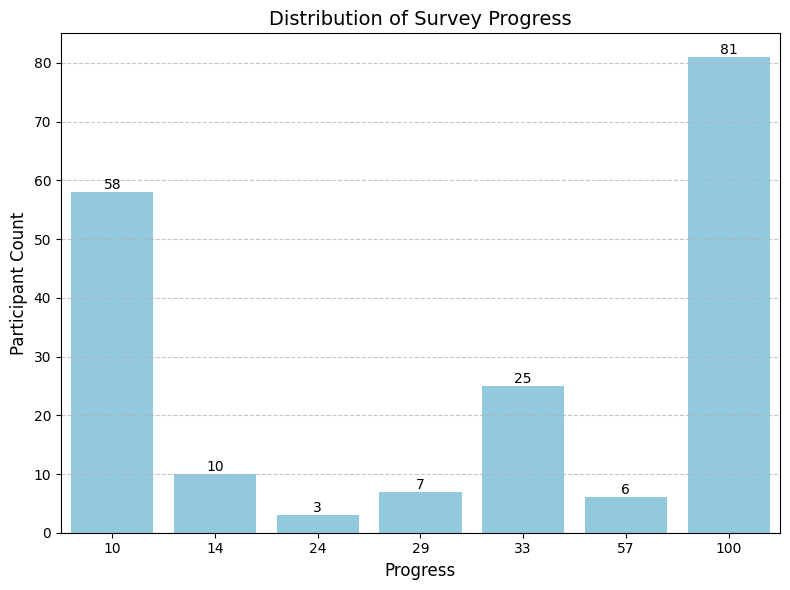

In [7]:
plt.figure(figsize=(8,6))

ax = sns.countplot(
    data=survey_df.sort_values(by='Progress'),
    x='Progress',
    color='skyblue'  
)

# Add grid lines
ax.yaxis.grid(True, linestyle='--', alpha=0.7)

# Add labels on bars
for container in ax.containers:
    ax.bar_label(container, label_type='edge', fontsize=10)

# Titles and labels
plt.title('Distribution of Survey Progress', fontsize=14)
plt.xlabel('Progress', fontsize=12)
plt.ylabel('Participant Count', fontsize=12)

plt.tight_layout()
plt.savefig("Data/Outbound/Graphs/Distribution of Survey Progress.png", dpi=300, bbox_inches="tight")
plt.show()

### Age

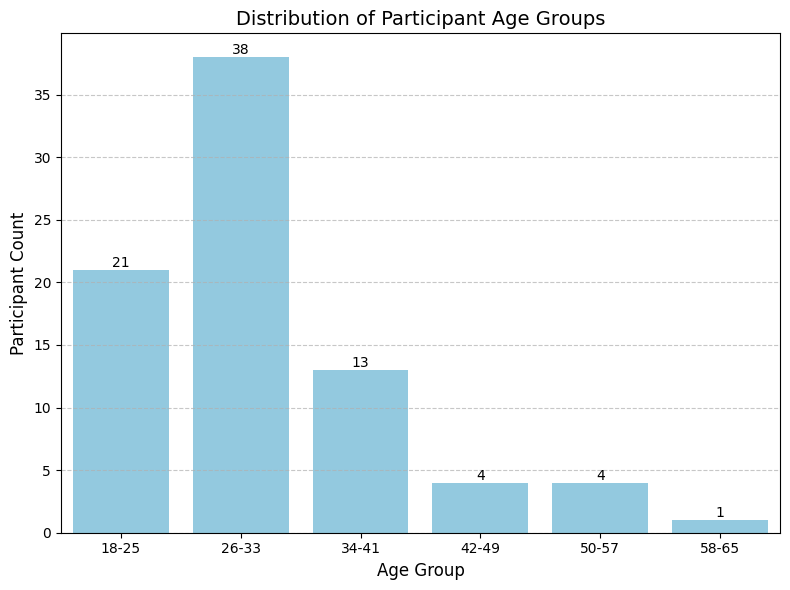

In [8]:
plt.figure(figsize=(8,6))

ax = sns.countplot(
    data=survey_df.sort_values(by='Q14'),
    x='Q14',
    color='skyblue'
)

# Add grid lines
ax.yaxis.grid(True, linestyle='--', alpha=0.7)

# Add labels on bars
for container in ax.containers:
    ax.bar_label(container, label_type='edge', fontsize=10)

# Titles and labels
plt.title('Distribution of Participant Age Groups', fontsize=14)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Participant Count', fontsize=12)

plt.tight_layout()
plt.savefig("Data/Outbound/Graphs/Distribution of Participant Age Groups.png", dpi=300, bbox_inches="tight")
plt.show()

### Gender

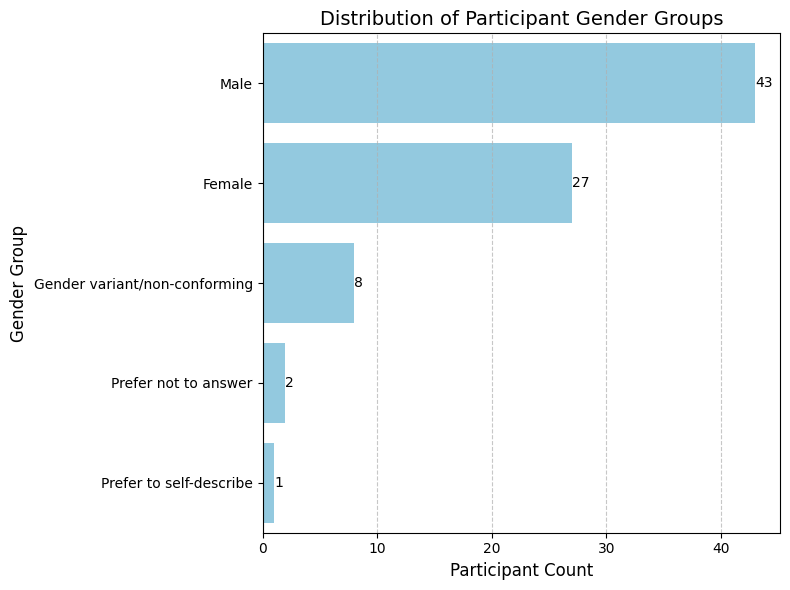

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# Get order of Q15 categories sorted by frequency
order = survey_df['Q15'].value_counts().index

ax = sns.countplot(
    data=survey_df,
    y='Q15',              # horizontal bars
    order=order,          # sort by frequency
    color='skyblue'
)

# Add grid lines
ax.xaxis.grid(True, linestyle='--', alpha=0.7)

# Add labels on bars
for container in ax.containers:
    ax.bar_label(container, label_type='edge', fontsize=10)

# Titles and labels
plt.title('Distribution of Participant Gender Groups', fontsize=14)
plt.xlabel('Participant Count', fontsize=12)
plt.ylabel('Gender Group', fontsize=12)

plt.tight_layout()
plt.savefig("Data/Outbound/Graphs/Distribution of Participant Gender Groups.png", dpi=300, bbox_inches="tight")
plt.show()


### Occupation

In [10]:
survey_df['Q16'].value_counts()

No     75
Yes     6
Name: Q16, dtype: int64

## Term Analysis 

In [11]:
term_df.head(3)

,metadata.ResponseId,metadata.Finished,metadata.Progress,metadata.TermTrack,metadata.QuestionId,QX_X.UserProvidedMoodTerm,QX_X.CleanedMoodTerm,QX_X.CleanedTermStem,QX_X.RemovedTermFlag,QX_X.UserCategoryMapping,QX.MultipleCategoryTerm,QX#1_X.MultipleCategoryMapping,QX#2_X_1.UserProvidedCategory,QX#2_X_1.CleanedCategory
0,R_1M0P04gYkqgIfoB,True,100,Recent,Q2_1,Cozy,cozy,cozi,False,Peaceful,False,NaN,NaN,NaN
1,R_1M0P04gYkqgIfoB,True,100,Recent,Q2_2,Peaceful,peaceful,peac,False,Peaceful,False,NaN,NaN,NaN
2,R_1M0P04gYkqgIfoB,True,100,Recent,Q2_3,Homey,homey,homey,False,Light-hearted,False,NaN,NaN,NaN


In [12]:
#Only keep kept terms
term_df = term_df[term_df['QX_X.RemovedTermFlag']== False].reset_index(drop=True)

### Frequency and Distribution

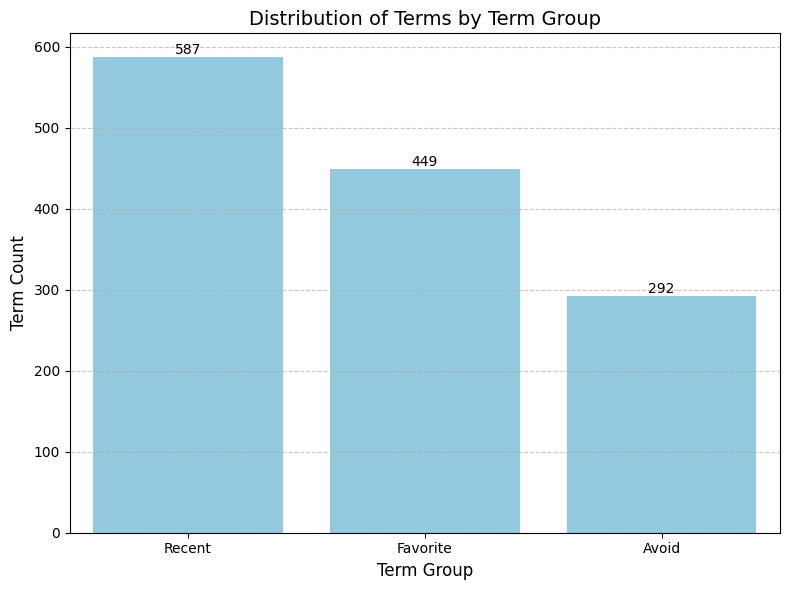

In [13]:
plt.figure(figsize=(8,6))

order = term_df['metadata.TermTrack'].value_counts().index

ax = sns.countplot(
    data=term_df.sort_values(by='metadata.TermTrack'),
    x='metadata.TermTrack',
    color='skyblue',
    order= order  # makes all bars the same color
)

# Add grid lines
ax.yaxis.grid(True, linestyle='--', alpha=0.7)

# Add labels on bars
for container in ax.containers:
    ax.bar_label(container, label_type='edge', fontsize=10)

# Titles and labels
plt.title('Distribution of Terms by Term Group', fontsize=14)
plt.xlabel('Term Group', fontsize=12)
plt.ylabel('Term Count', fontsize=12)

plt.tight_layout()
plt.savefig("Data/Outbound/Graphs/Distribution of Stems by Term Group.png", dpi=300, bbox_inches="tight")
plt.show()

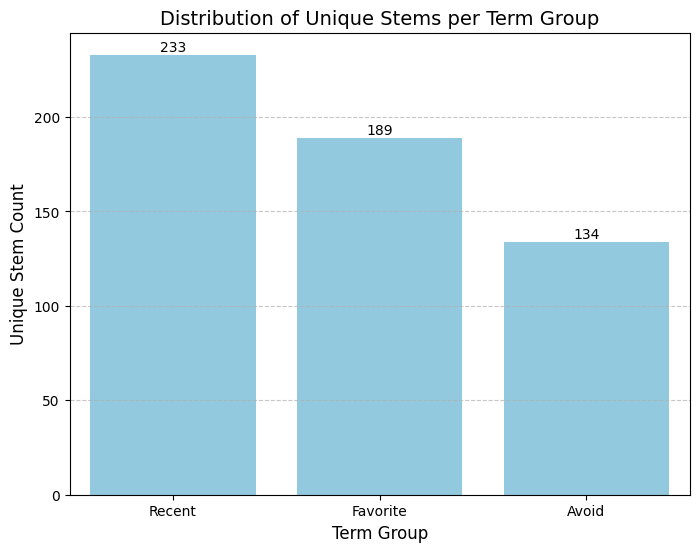

In [14]:
# Deduplicate by Term Group + CleanedTermStem
dedup_df = term_df.drop_duplicates(subset=['metadata.TermTrack', 'QX_X.CleanedTermStem'])

plt.figure(figsize=(8,6))
ax = sns.countplot(
    data=dedup_df,
    x='metadata.TermTrack',
    color='skyblue'
)

# Add labels
for container in ax.containers:
    ax.bar_label(container, label_type='edge', fontsize=10)

ax.yaxis.grid(True, linestyle='--', alpha=0.7)
plt.title('Distribution of Unique Stems per Term Group', fontsize=14)
plt.xlabel('Term Group', fontsize=12)
plt.ylabel('Unique Stem Count', fontsize=12)
plt.savefig("Data/Outbound/Graphs/Distribution of Unique Stems per Term Group.png", dpi=300, bbox_inches="tight")
plt.show()


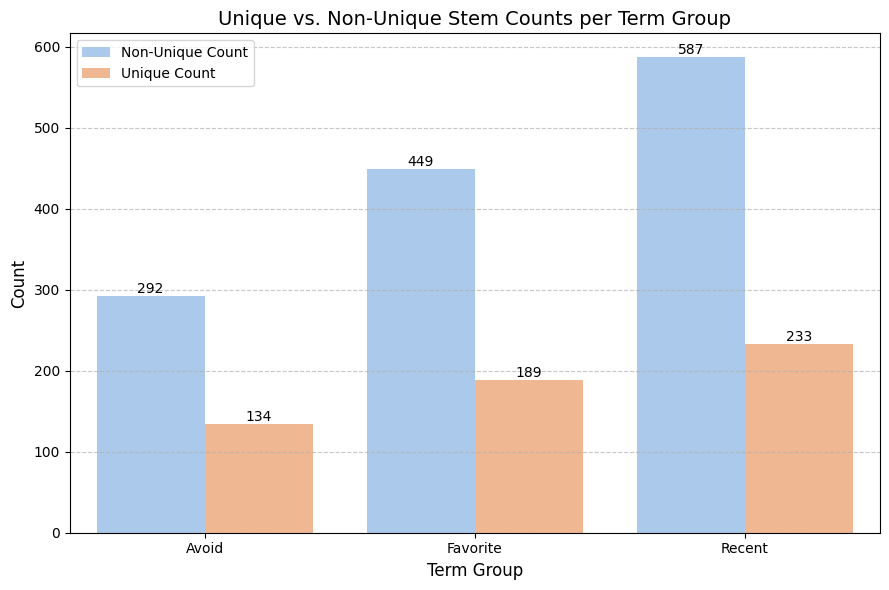

In [15]:
# --- counts per Term Group ---
non_unique = (
    term_df.groupby('metadata.TermTrack')
           .size()
           .rename('Non-Unique Count')
)

unique = (
    term_df.groupby('metadata.TermTrack')['QX_X.CleanedTermStem']
           .nunique()
           .rename('Unique Count')
)

summary = pd.concat([non_unique, unique], axis=1).reset_index()

# Long form for seaborn
long_df = summary.melt(
    id_vars='metadata.TermTrack',
    value_vars=['Non-Unique Count', 'Unique Count'],
    var_name='Count Type',
    value_name='Count'
)

plt.figure(figsize=(9,6))
ax = sns.barplot(
    data=long_df,
    x='metadata.TermTrack',
    y='Count',
    hue='Count Type',
    palette='pastel'
)

# Grid + labels on bars
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
for c in ax.containers:
    ax.bar_label(c, fontsize=10, label_type='edge')

plt.title('Unique vs. Non-Unique Stem Counts per Term Group', fontsize=14)
plt.xlabel('Term Group', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(title='')
plt.tight_layout()
plt.savefig("Data/Outbound/Graphs/Unique vs Non-Unique Stem Counts per Term Group.png", dpi=300, bbox_inches="tight")
plt.show()


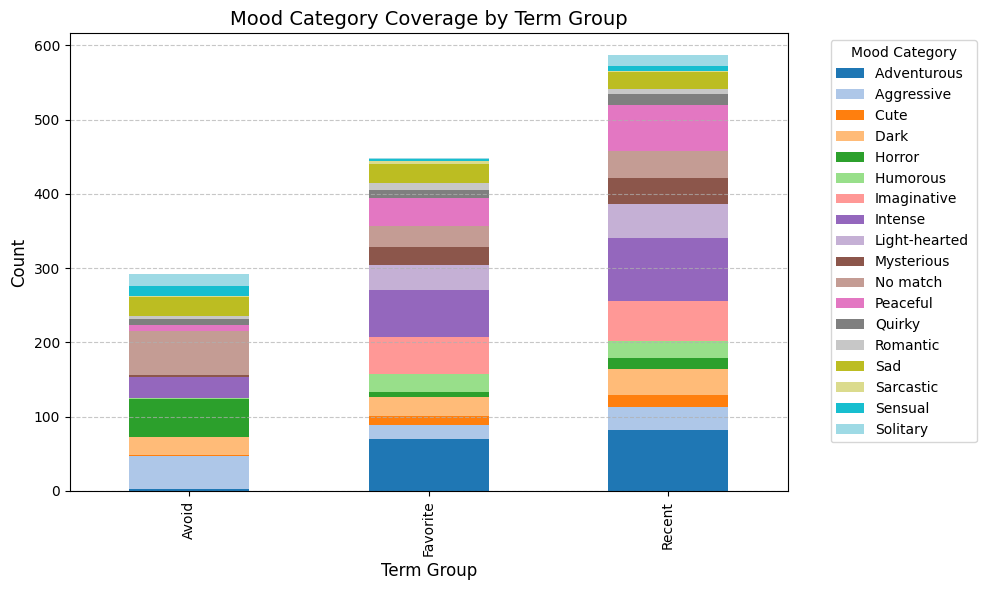

In [16]:
# Cross-tab: Term Group × Mood Category
ct = pd.crosstab(
    term_df['metadata.TermTrack'],
    term_df['QX_X.UserCategoryMapping']
)

# Reorder columns alphabetically
categories = sorted(ct.columns)
ct = ct[categories]

# Plot stacked bar chart
ax = ct.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6),
    colormap="tab20"
)

# Grid lines
ax.yaxis.grid(True, linestyle="--", alpha=0.7)

# Titles and labels
plt.title("Mood Category Coverage by Term Group", fontsize=14)
plt.xlabel("Term Group", fontsize=12)
plt.ylabel("Count", fontsize=12)

# Legend in alphabetical order
plt.legend(
    title="Mood Category",
    labels=categories,
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.savefig("Data/Outbound/Graphs/Mood Category Coverage by Term Group.png", dpi=300, bbox_inches="tight")
plt.show()


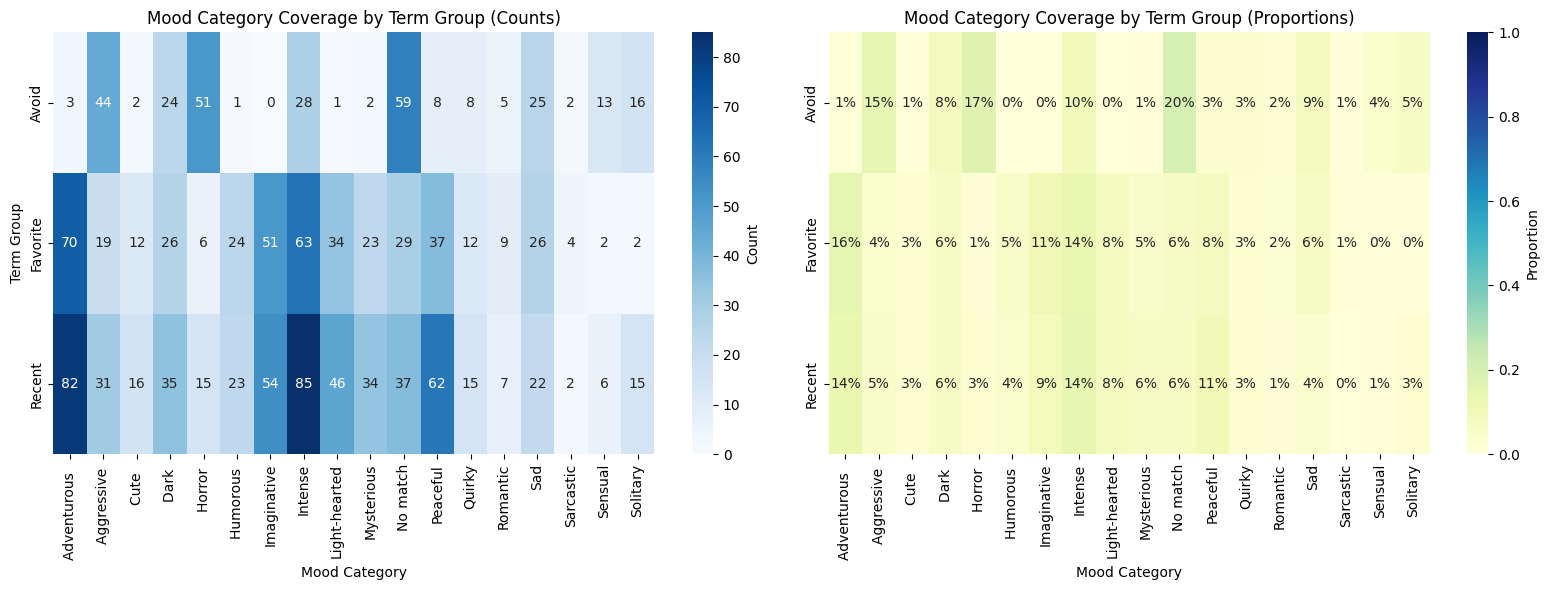

In [17]:
# Cross-tab: Term Group × Mood Category
ct = pd.crosstab(
    term_df['metadata.TermTrack'],
    term_df['QX_X.UserCategoryMapping']
)

# Order rows/columns alphabetically so heatmap & legend are consistent
rows = sorted(ct.index)
cols = sorted(ct.columns)
ct = ct.loc[rows, cols]

# Row-normalized (proportions) for a second heatmap
ct_norm = ct.div(ct.sum(axis=1), axis=0).fillna(0)

# Create the two heatmaps
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1) Counts heatmap
sns.heatmap(
    ct,
    ax=axes[0],
    annot=True, fmt="d",
    cmap="Blues",
    cbar_kws={"label": "Count"}
)
axes[0].set_title("Mood Category Coverage by Term Group (Counts)")
axes[0].set_xlabel("Mood Category")
axes[0].set_ylabel("Term Group")

# 2) Proportions heatmap (each row sums to 100%)
# Build percentage labels for annotation
annot_pct = (ct_norm * 100).round(0).astype(int).astype(str) + "%"

sns.heatmap(
    ct_norm,
    ax=axes[1],
    annot=annot_pct, fmt="",
    cmap="YlGnBu",
    vmin=0, vmax=1,
    cbar_kws={"label": "Proportion"}
)
axes[1].set_title("Mood Category Coverage by Term Group (Proportions)")
axes[1].set_xlabel("Mood Category")
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig("Data/Outbound/Graphs/Mood Category Coverage by Term Group.png", dpi=300, bbox_inches="tight")
plt.show()


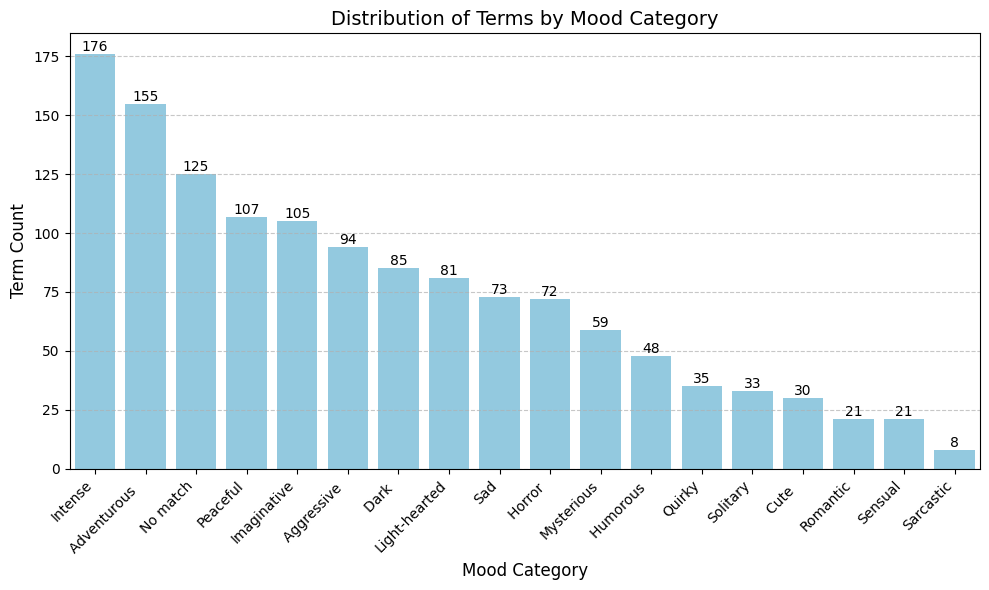

In [18]:
plt.figure(figsize=(10,6))

# Sort mood categories by frequency
order = term_df['QX_X.UserCategoryMapping'].value_counts().index

ax = sns.countplot(
    data=term_df,
    x='QX_X.UserCategoryMapping',
    color='skyblue',
    order=order
)

# Add grid lines
ax.yaxis.grid(True, linestyle='--', alpha=0.7)

# Add labels on bars
for container in ax.containers:
    ax.bar_label(container, label_type='edge', fontsize=10)

# Titles and labels (updated)
plt.title('Distribution of Terms by Mood Category', fontsize=14)
plt.xlabel('Mood Category', fontsize=12)
plt.ylabel('Term Count', fontsize=12)

plt.xticks(rotation=45, ha='right')  # rotate labels if they are long
plt.tight_layout()
plt.savefig("Data/Outbound/Graphs/Distribution of Terms by Mood Category.png", dpi=300, bbox_inches="tight")
plt.show()


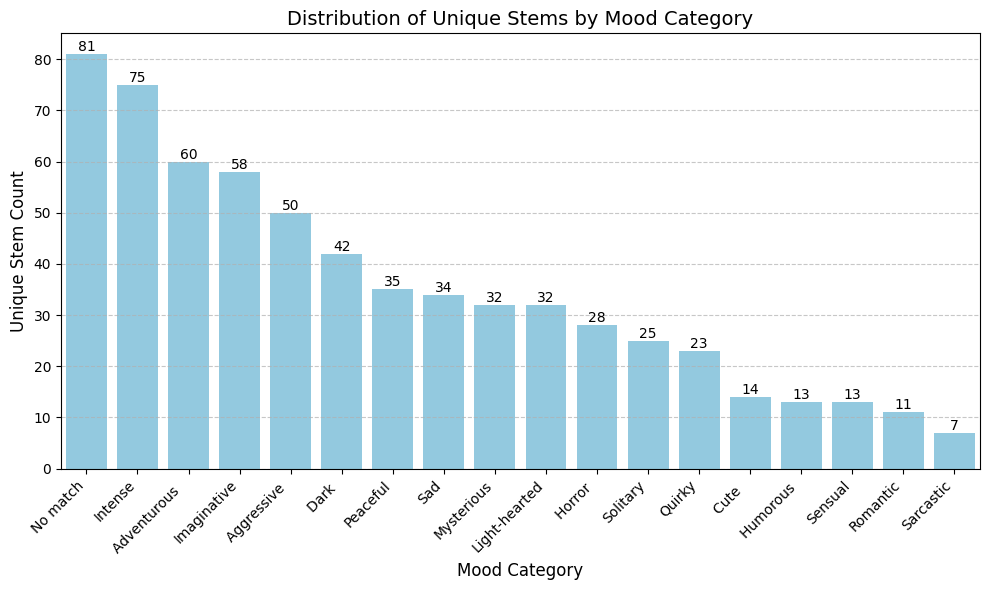

In [19]:
plt.figure(figsize=(10,6))

# Deduplicate by mood category + cleaned stem
dedup_df = term_df.drop_duplicates(
    subset=['QX_X.UserCategoryMapping', 'QX_X.CleanedTermStem']
)

# Order mood categories by unique frequency
order = dedup_df['QX_X.UserCategoryMapping'].value_counts().index

ax = sns.countplot(
    data=dedup_df,
    x='QX_X.UserCategoryMapping',
    color='skyblue',
    order=order
)

# Add grid lines
ax.yaxis.grid(True, linestyle='--', alpha=0.7)

# Add labels on bars
for container in ax.containers:
    ax.bar_label(container, label_type='edge', fontsize=10)

# Titles and labels
plt.title('Distribution of Unique Stems by Mood Category', fontsize=14)
plt.xlabel('Mood Category', fontsize=12)
plt.ylabel('Unique Stem Count', fontsize=12)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("Data/Outbound/Graphs/Distribution of Unique Stems by Mood Category.png", dpi=300, bbox_inches="tight")
plt.show()


### Relationship

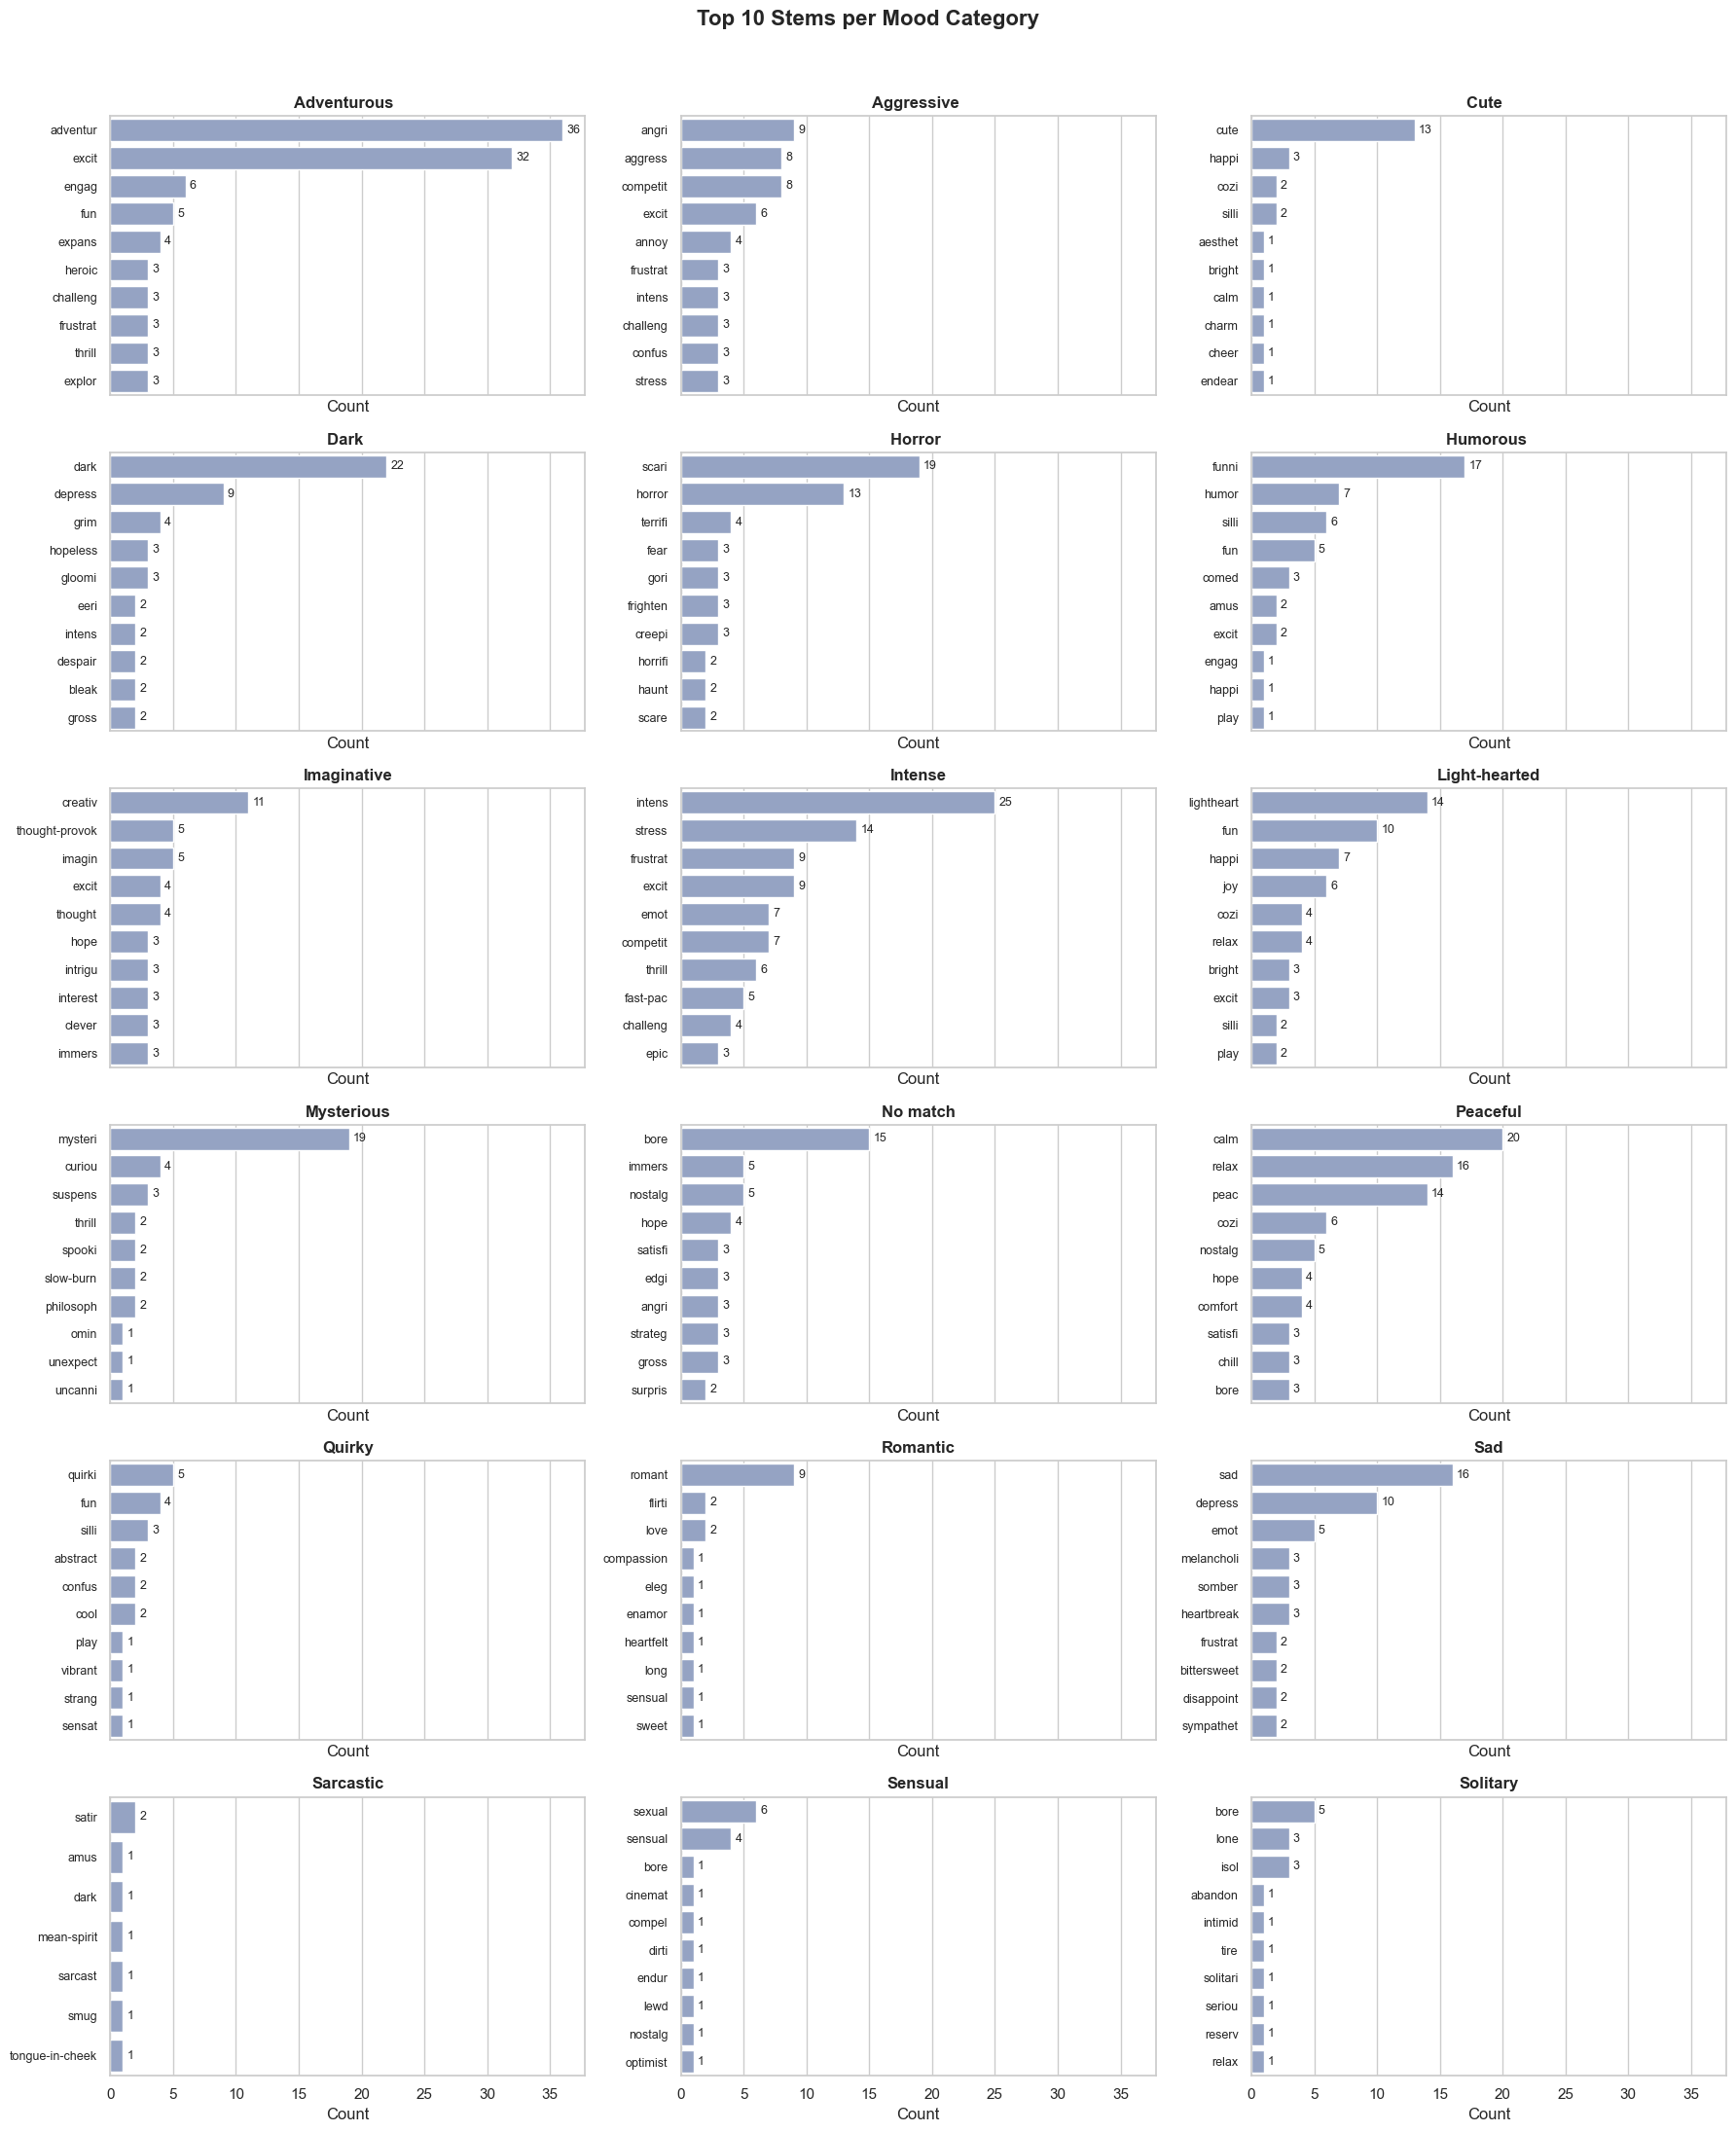

In [20]:
# --- Prep: counts per (category, stem) ---
counts = (
    term_df
    .groupby(['QX_X.UserCategoryMapping', 'QX_X.CleanedTermStem'])
    .size()
    .reset_index(name='count')
)

# Category order (alphabetical here; can change to frequency order)
categories = sorted(counts['QX_X.UserCategoryMapping'].unique())

# Plot settings
sns.set_theme(style="whitegrid")
n_rows, n_cols = 6, 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 22), sharex=True)
axes = axes.flatten()

# Pick one Seaborn color for all bars
bar_color = sns.color_palette("Set2")[2]

for i, cat in enumerate(categories):
    ax = axes[i]
    sub = (
        counts[counts['QX_X.UserCategoryMapping'] == cat]
        .sort_values('count', ascending=False)   # descending order
        .head(10)
    )

    sns.barplot(
        data=sub,
        x="count",
        y="QX_X.CleanedTermStem",
        ax=ax,
        color=bar_color,    # same color for all bars
        orient="h",
        order=sub["QX_X.CleanedTermStem"]  # ensures descending order in plot
    )

    # Add labels on bars
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', fontsize=9, padding=3)

    ax.set_title(cat, fontsize=12, weight="bold")
    ax.set_xlabel("Count")
    ax.set_ylabel("")

    ax.tick_params(axis="y", labelsize=9)

# Remove extra axes if fewer than grid size
for j in range(len(categories), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Top 10 Stems per Mood Category", fontsize=16, weight="bold", y=0.995)
fig.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig("Data/Outbound/Graphs/Top 10 Stems per Mood Category.png", dpi=300, bbox_inches="tight")
plt.show()


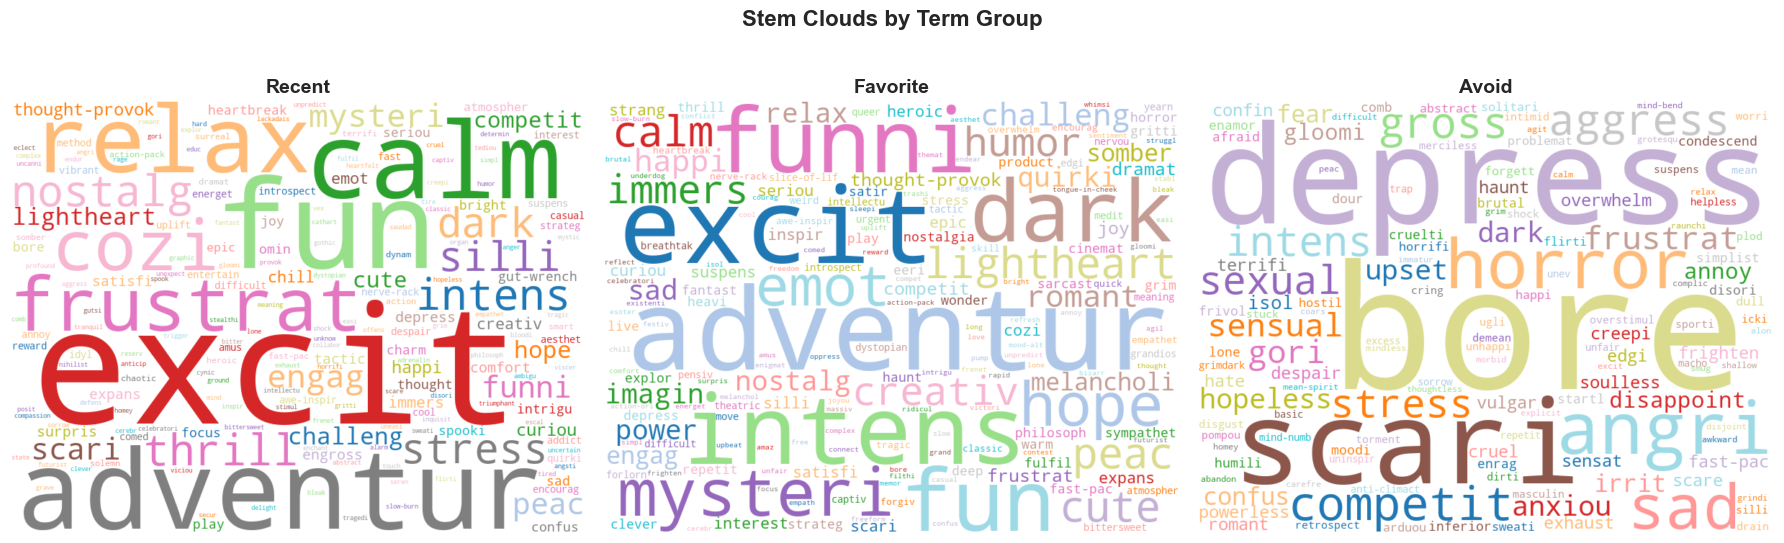

In [21]:
# ---- CONFIG ----
term_col = 'QX_X.CleanedTermStem'          # change to your preferred term column
group_col = 'metadata.TermTrack'           # the 3 buckets: e.g., Recent/Favorite/Avoid
groups_in_order = ['Recent', 'Favorite', 'Avoid']  # adjust to your exact labels

# Build frequency dict per group (non-unique counts)
freq_by_group = {}
for g in groups_in_order:
    sub = term_df[term_df[group_col] == g]
    if sub.empty:
        freq_by_group[g] = {}
    else:
        freq_by_group[g] = sub[term_col].value_counts().to_dict()

# WordCloud settings (tweak as you like)
wc_kwargs = dict(
    width=800,
    height=600,
    background_color="white",
    prefer_horizontal=1.0,
    colormap="tab20",          # consistent, pleasant palette
    max_words=200,
    min_font_size=8,
    relative_scaling=0.5,      # weight by frequency
    normalize_plurals=False,
    stopwords=STOPWORDS        # add custom stopwords if needed
)

# Plot 1x3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, g in zip(axes, groups_in_order):
    wc = WordCloud(**wc_kwargs)
    # If no terms for a group, display a blank cloud
    words = freq_by_group[g]
    if len(words) == 0:
        ax.text(0.5, 0.5, 'No terms', ha='center', va='center', fontsize=14)
        ax.set_title(g, fontsize=14, fontweight='bold')
        ax.axis('off')
        continue
    wc.generate_from_frequencies(words)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(g, fontsize=14, fontweight='bold')
    ax.axis('off')

fig.suptitle('Stem Clouds by Term Group', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig("Data/Outbound/Graphs/Stem Clouds by Term Group.png", dpi=300, bbox_inches="tight")
plt.show()


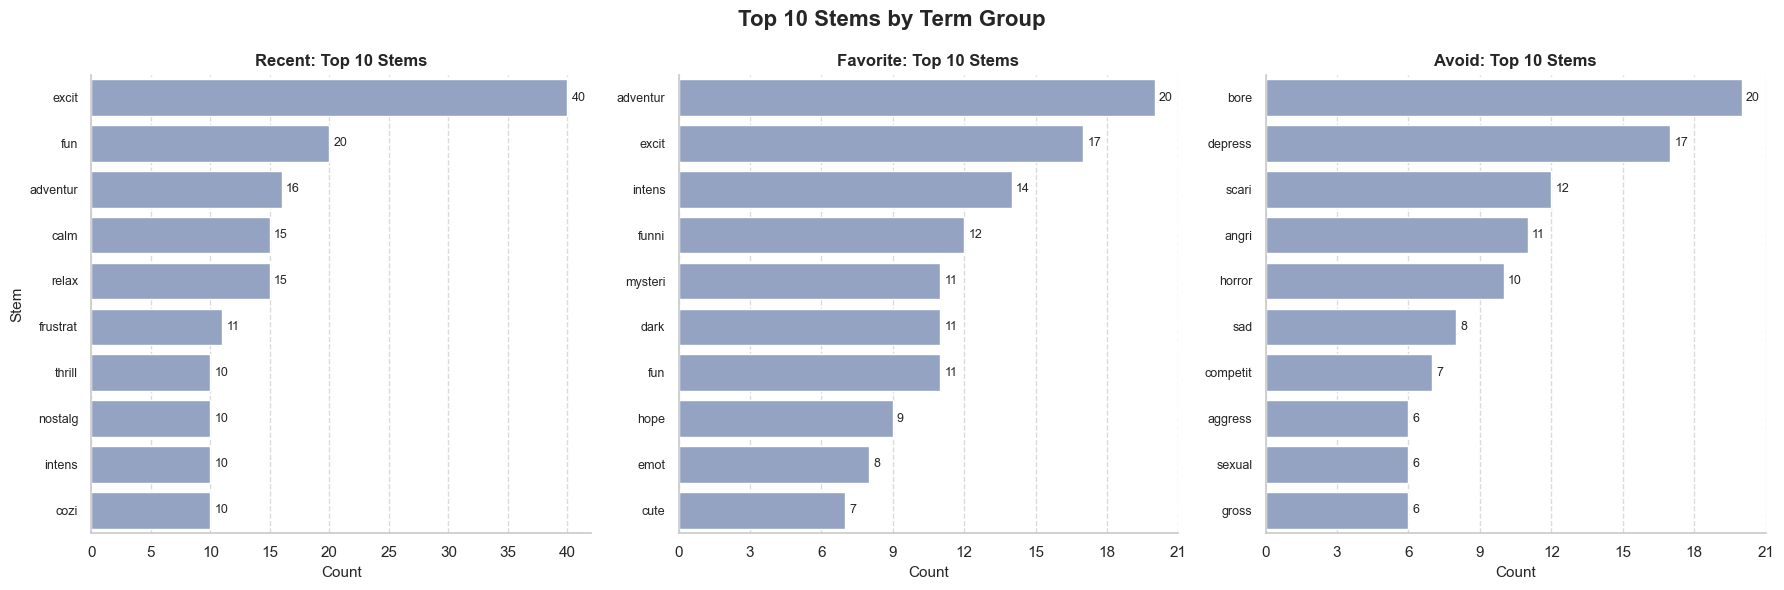

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator

# --- config ---
term_col  = 'QX_X.CleanedTermStem'
group_col = 'metadata.TermTrack'
groups_in_order = ['Recent', 'Favorite', 'Avoid']  # adjust if your labels differ

# prep: counts per (term group, stem)
counts = (
    term_df
    .dropna(subset=[group_col, term_col])
    .groupby([group_col, term_col])
    .size()
    .reset_index(name='count')
)

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=False)
bar_color = sns.color_palette("Set2")[2]

for ax, grp in zip(axes, groups_in_order):
    sub = (
        counts[counts[group_col] == grp]
        .sort_values('count', ascending=False)
        .head(10)
        .copy()
    )

    # ensure descending order in the plot (largest at top)
    order = sub.sort_values('count', ascending=False)[term_col].tolist()

    sns.barplot(
        data=sub,
        x='count', y=term_col,
        order=order,
        orient='h',
        color=bar_color,
        ax=ax
    )

    # labels on bars
    for c in ax.containers:
        ax.bar_label(c, fmt='%d', padding=3, fontsize=9)

    ax.set_title(f'{grp}: Top 10 Stems', fontsize=12, weight='bold')
    ax.set_xlabel('Count', fontsize=11)
    ax.set_ylabel('' if grp != groups_in_order[0] else 'Stem', fontsize=11)
    ax.yaxis.set_tick_params(labelsize=9)
    ax.xaxis.grid(True, linestyle='--', alpha=0.7)
    ax.spines[['top','right']].set_visible(False)

    # ✅ Force integer ticks only
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

# handle missing groups: blank panels if any
for j in range(len(groups_in_order), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Top 10 Stems by Term Group', fontsize=16, weight='bold', y=0.98)
plt.tight_layout()
plt.savefig("Data/Outbound/Graphs/Top 10 Stems by Term Group.png", dpi=300, bbox_inches="tight")
plt.show()


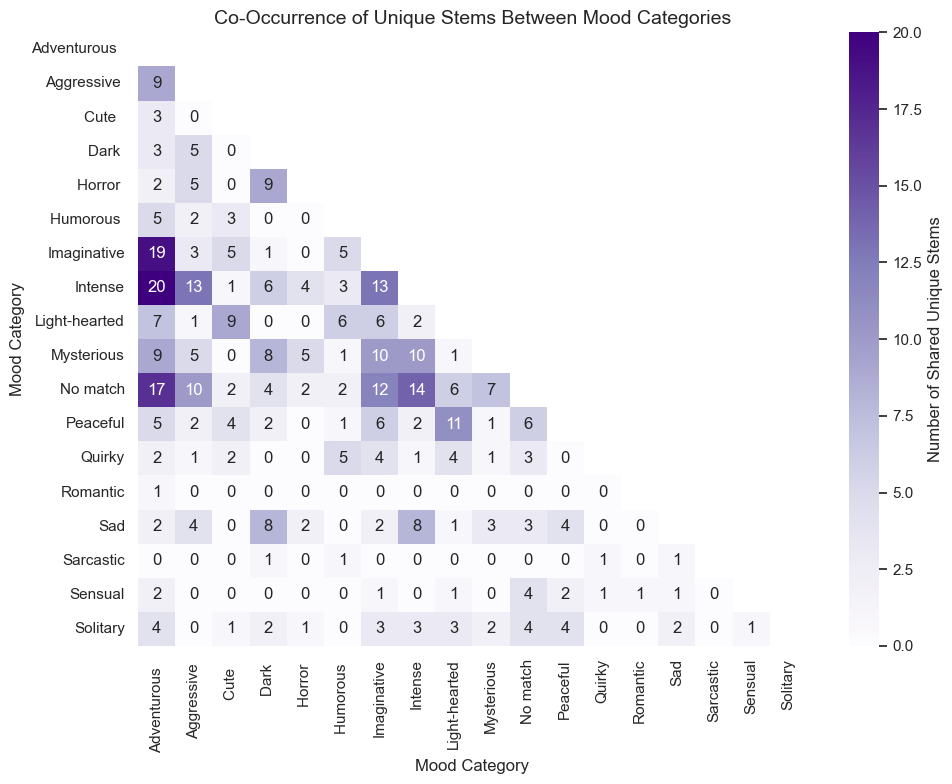

In [23]:
# Build dictionary of {category: set of stems}
category_terms = (
    term_df.groupby('QX_X.UserCategoryMapping')['QX_X.CleanedTermStem']
    .apply(set)
    .to_dict()
)

categories = sorted(category_terms.keys())

# Build overlap matrix (floats so we can hold NaN)
overlap = pd.DataFrame(0.0, index=categories, columns=categories)

for c1 in categories:
    for c2 in categories:
        overlap.loc[c1, c2] = len(category_terms[c1].intersection(category_terms[c2]))

# Remove diagonal
np.fill_diagonal(overlap.values, np.nan)

# Mask upper triangle
mask = np.triu(np.ones_like(overlap, dtype=bool))

# Plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(
    overlap,
    annot=True, fmt=".0f",   # no decimals, blanks where NaN
    cmap="Purples",
    cbar_kws={'label': 'Number of Shared Unique Stems'},
    mask=mask,
    vmin=0,
    vmax=np.nanmax(overlap.values)   # scale 0 → max
)

plt.title("Co-Occurrence of Unique Stems Between Mood Categories", fontsize=14)
plt.xlabel("Mood Category")
plt.ylabel("Mood Category")
plt.tight_layout()
plt.savefig("Data/Outbound/Graphs/Co-Occurrence of Unique Stems Between Mood Categories.png", dpi=300, bbox_inches="tight")
plt.show()


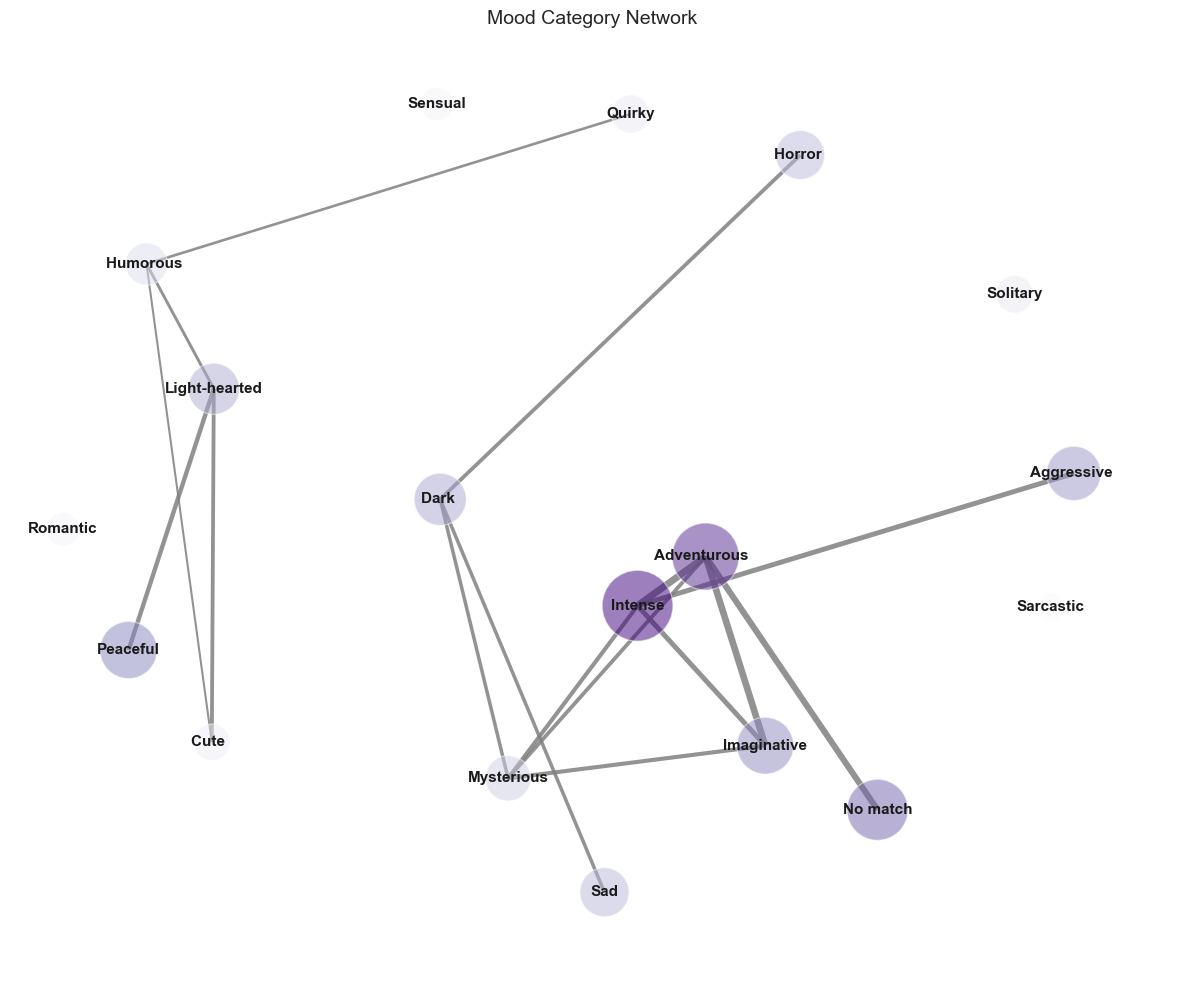

In [24]:
# pip install networkx if needed

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from matplotlib.colors import Normalize
from matplotlib.cm import get_cmap, ScalarMappable

# --- columns ---
TERM_COL = 'QX_X.CleanedTermStem'          # stem text
CAT_COL  = 'QX_X.UserCategoryMapping'      # mood category

# --- thresholds ---
MIN_JACCARD = 0.10

# =========================
# Totals per category (NON-UNIQUE)
# =========================
# counts every row (not unique stems)
total_terms = (
    term_df
    .dropna(subset=[CAT_COL, TERM_COL])
    .groupby(CAT_COL)[TERM_COL]
    .size()
)

categories = sorted(total_terms.index.tolist())

# =========================
# Sets per category (for overlap/jaccard)
# =========================
category_terms = (
    term_df
    .dropna(subset=[CAT_COL, TERM_COL])
    .groupby(CAT_COL)[TERM_COL]
    .apply(set)
    .to_dict()
)

# =========================
# Build edges by Jaccard
# =========================
edges = []
for i, c1 in enumerate(categories):
    s1 = category_terms.get(c1, set())
    for j, c2 in enumerate(categories):
        if j <= i:
            continue
        s2 = category_terms.get(c2, set())
        inter = len(s1 & s2)
        union = len(s1 | s2) if (s1 or s2) else 1
        jacc = inter / union
        if jacc >= MIN_JACCARD and inter > 0:
            edges.append((c1, c2, inter, jacc))  # use inter for edge weight

# =========================
# Build graph
# =========================
G = nx.Graph()
# Nodes with attribute: total non-unique terms
for c in categories:
    G.add_node(c, total=total_terms.loc[c])

# Edges with weight = shared unique stems
for u, v, inter, jacc in edges:
    G.add_edge(u, v, weight=inter, jaccard=jacc)

if G.number_of_nodes() == 0 or G.number_of_edges() == 0:
    print("Graph is empty after filtering. Try lowering MIN_JACCARD.")
else:
    # =========================
    # Node sizes & colors by TOTAL TERMS
    # =========================
    totals = np.array([G.nodes[n]['total'] for n in G.nodes()], dtype=float)
    t_min, t_max = totals.min(), totals.max()

    # sizes: 400 ~ 2600 range
    if t_max == t_min:
        node_sizes = np.full_like(totals, 1200.0)
    else:
        node_sizes = 400 + 2200 * (totals - t_min) / (t_max - t_min)

    # colors: Purples colormap
    cmap = get_cmap('Purples')
    norm = Normalize(vmin=t_min, vmax=t_max)
    node_colors = [cmap(norm(G.nodes[n]['total'])) for n in G.nodes()]

    # =========================
    # Edge widths by shared stems (weight)
    # =========================
    w = np.array([G[u][v]['weight'] for u, v in G.edges()], dtype=float)
    if w.size == 0 or w.max() == w.min():
        widths = np.full_like(w, 2.0)
    else:
        widths = 1.5 + 3.5 * (w - w.min()) / (w.max() - w.min())

    # =========================
    # Layout (spread nodes to reduce overlap)
    # =========================
    pos = nx.spring_layout(G, k=21, seed=42, iterations=400)  # larger k = more spread

    # =========================
    # Draw
    # =========================
    plt.figure(figsize=(12, 10))

    nx.draw_networkx_nodes(
        G, pos,
        node_size=node_sizes,
        node_color=node_colors,
        edgecolors='white',
        linewidths=0.9,
        alpha=0.5
    )

    nx.draw_networkx_edges(
        G, pos,
        width=widths,
        edge_color='gray',     # no color mapping, keep weighting
        alpha=0.85
    )

    nx.draw_networkx_labels(G, pos, font_size=11, font_weight='bold')

    # Colorbar for node totals
    sm = ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    # cbar = plt.colorbar(sm, fraction=0.046, pad=0.04)
    # cbar.set_label('Total terms per category (non-unique)')

    plt.title('Mood Category Network', fontsize=14)
    plt.axis('off')
    plt.tight_layout()
    plt.savefig("Data/Outbound/Graphs/Mood Category Network.png", dpi=300, bbox_inches="tight")
    plt.show()


## Testing

In [29]:
term_df[term_df['QX_X.UserCategoryMapping']=='Peaceful']

,metadata.ResponseId,metadata.Finished,metadata.Progress,metadata.TermTrack,metadata.QuestionId,QX_X.UserProvidedMoodTerm,QX_X.CleanedMoodTerm,QX_X.CleanedTermStem,QX_X.RemovedTermFlag,QX_X.UserCategoryMapping,QX.MultipleCategoryTerm,QX#1_X.MultipleCategoryMapping,QX#2_X_1.UserProvidedCategory,QX#2_X_1.CleanedCategory
0,R_1M0P04gYkqgIfoB,True,100,Recent,Q2_1,Cozy,cozy,cozi,False,Peaceful,False,NaN,NaN,NaN
1,R_1M0P04gYkqgIfoB,True,100,Recent,Q2_2,Peaceful,peaceful,peac,False,Peaceful,False,NaN,NaN,NaN
3,R_1M0P04gYkqgIfoB,True,100,Recent,Q2_4,Nostalgic,nostalgic,nostalg,False,Peaceful,True,"['Light-hearted', 'Peaceful']",NaN,NaN
4,R_1M0P04gYkqgIfoB,True,100,Recent,Q2_5,Tranquil,tranquil,tranquil,False,Peaceful,False,NaN,NaN,NaN
5,R_1M0P04gYkqgIfoB,True,100,Recent,Q2_6,Comforting,comforting,comfort,False,Peaceful,False,NaN,NaN,NaN
9,R_6hA6yOKSGzPDXlp,True,100,Recent,Q2_1,Solemn,solemn,solemn,False,Peaceful,False,NaN,NaN,NaN
11,R_6hA6yOKSGzPDXlp,True,100,Recent,Q2_3,Calm,calm,calm,False,Peaceful,False,NaN,NaN,NaN
12,R_34jUAPsFHDjPeyy,True,100,Recent,Q2_1,relaxing,relaxing,relax,False,Peaceful,False,NaN,NaN,NaN
25,R_7s8WZ7aK1AxrUYN,True,100,Recent,Q2_3,#Patience,patience,patienc,False,Peaceful,False,NaN,NaN,NaN
70,R_2G1wZjbTkRpEPVM,True,100,Recent,Q2_1,Calming,calming,calm,False,Peaceful,False,NaN,NaN,NaN
